# 24. Nonstationary frequency analysis

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

A frequency analysis assumes the record is a sample from one fixed distribution. Land
use changes, reservoirs are built, and the climate that produces the storms is not the
one that produced them fifty years ago. When the assumption fails, the honest response
is to let a distribution parameter vary with time and see whether the data supports it.

This example attaches a linear trend to the location parameter of a GEV distribution
with `trend()`, fits stationary and nonstationary versions of the same record, and
compares them. It has no upstream counterpart: the USACE-RMC Numerics-Python-Examples
repository has no nonstationary example.

## What you'll learn

- Attach a trend to one distribution parameter and see how it reshapes the parameter
  vector.
- Fit stationary and nonstationary models of the same record.
- Compare them on AIC, BIC, and DIC, and read what each one is telling you.

## Setup

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import corehydropy as ch

## A record with a rising mean

Sixty years of annual peaks, drawn from a GEV whose location rises by 120 cfs a year.
The draws come from the package's own seeded generator, so the series is reproducible
in either language.

In [2]:
noise = ch.Distribution("GeneralizedExtremeValue", [0, 1, 0.05]).random(60, seed=20250811)
peaks = np.round(8000 + 120 * np.arange(60) + 1800 * np.asarray(noise))

print(f"first 20 years: {np.mean(peaks[:20]):,.0f} cfs mean")
print(f" last 20 years: {np.mean(peaks[-20:]):,.0f} cfs mean")

first 20 years: 10,210 cfs mean
 last 20 years: 14,754 cfs mean


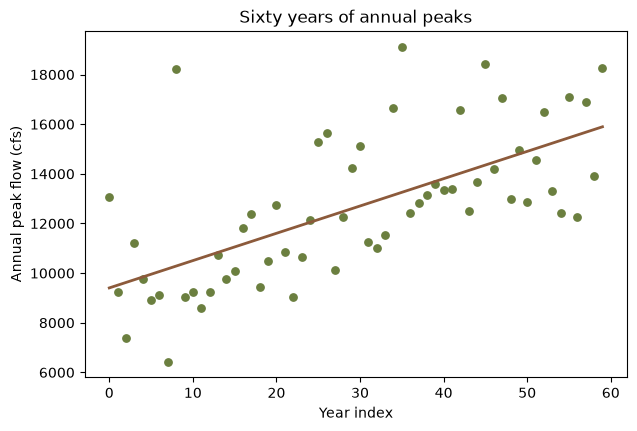

In [3]:
year = np.arange(60)
slope, intercept = np.polyfit(year, peaks, 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(year, peaks, s=28, color="#6b7f3f")
ax.plot(year, intercept + slope * year, color="#8c5a3b", lw=2)
ax.set_xlabel("Year index")
ax.set_ylabel("Annual peak flow (cfs)")
ax.set_title("Sixty years of annual peaks")
plt.show()

## Attaching a trend

`trend()` names the parameter to vary and the shape of the variation. The parameter can
be named (`"location"`, or the library's `ξ`) or given as a 1-based position.

In [4]:
stationary = ch.model_univariate("GeneralizedExtremeValue", peaks)
nonstationary = ch.model_univariate(
    "GeneralizedExtremeValue", peaks, trends=ch.trend("location", "Linear")
)
nonstationary

<Model univariate_distribution: GeneralizedExtremeValue (60 exact; 1 trends)>

A trend replaces its parameter with the trend's own coefficients, so the vector grows.
The GEV's three parameters become four: the location splits into an intercept and a
slope, and the scale and shape are unchanged.

In [5]:
print("stationary:   ",
      ", ".join(f"{v:.4f}" for v in ch.model_parameters(stationary)["values"]))
print("nonstationary:",
      ", ".join(f"{v:.4f}" for v in ch.model_log_likelihood(nonstationary)["parameters"]))

stationary:    11433.4018, 2780.9340, 0.1617
nonstationary: 11433.4018, 0.0000, 2780.9340, 0.1617


The slope starts at zero, which is what makes the comparison fair: the nonstationary
model begins at the stationary fit and has to earn the extra parameter.

## Fit both

In [6]:
aeps = [0.01, 0.02, 0.1, 0.5]

fit_st = ch.univariate_analysis(
    stationary, sampler="DEMCzs", iterations=1500, output_length=2000,
    seed=20250811, thinning_interval=1, exceedance_probabilities=aeps,
)
fit_ns = ch.univariate_analysis(
    nonstationary, sampler="DEMCzs", iterations=1500, output_length=2000,
    seed=20250811, thinning_interval=1, exceedance_probabilities=aeps,
)

aics = [fit_st["aic"], fit_ns["aic"]]
weights = [math.exp(-0.5 * (a - min(aics))) for a in aics]
weights = [w / sum(weights) for w in weights]

print(f"{'Model':<16}{'AIC':>10}{'BIC':>10}{'DIC':>10}{'AIC weight':>12}")
for label, fit, w in (("Stationary", fit_st, weights[0]),
                      ("Nonstationary", fit_ns, weights[1])):
    print(f"{label:<16}{fit['aic']:>10.2f}{fit['bic']:>10.2f}{fit['dic']:>10.2f}{w:>12.3f}")

Model                  AIC       BIC       DIC  AIC weight
Stationary         1206.64   1212.92   1132.47       0.000
Nonstationary      1187.57   1195.94   1089.38       1.000


All three criteria prefer the nonstationary model, and they should: the trend is real
and large. AIC and BIC both penalise the extra parameter and still come out ahead by
about 19 and 17 units; DIC, which measures the effective complexity over the whole
posterior rather than at a single point, prefers it by 43. An AIC difference of 19
corresponds to an evidence ratio of roughly 14,000 to 1.

Be careful reading this the other way round. A record with no trend will usually show
a small AIC *penalty* for the nonstationary fit, and that is the correct answer, not a
failure. The test earns its keep by being able to say no.

## What each fit says about the tail

In [7]:
print(f"{'AEP':>7}{'Return period':>16}{'Stationary':>13}{'Nonstationary':>15}")
for a, s, ns in zip(aeps, fit_st["mode_curve"], fit_ns["mode_curve"]):
    print(f"{a:>7}{'1 in ' + str(round(1 / a)):>16}{s:>13,.0f}{ns:>15,.0f}")

    AEP   Return period   Stationary  Nonstationary
   0.01        1 in 100       20,199         20,735
   0.02         1 in 50       19,320         19,259
    0.1         1 in 10       16,699         15,924
    0.5          1 in 2       12,482         12,371


The curves cross. The stationary fit sits above through the body of the distribution and
the nonstationary fit overtakes it at 1-in-100, which is the shape parameter doing its
work: the stationary fit has to absorb the rising mean as extra spread, landing on a
scale of 2,869 and a heavy shape of 0.194, while the nonstationary fit explains the same
rise with its slope and settles on a much tighter scale of 1,792 and a nearly Gumbel
shape of -0.039.

In [8]:
print(f"{'':<16}{'location':>12}{'scale':>12}{'shape':>10}")
for label, fit in (("Stationary", fit_st), ("Nonstationary", fit_ns)):
    p = fit["parameters"]
    print(f"{label:<16}{p[0]:>12.4f}{p[1]:>12.4f}{p[2]:>10.4f}")

                    location       scale     shape
Stationary        11466.9597   2869.2712    0.1939
Nonstationary     11709.9880   1791.8788   -0.0388


That is the substantive point. Ignoring a trend does not simply bias the mean; it
distorts the shape parameter, and the shape parameter is what governs how far the
design flow extrapolates beyond the record.

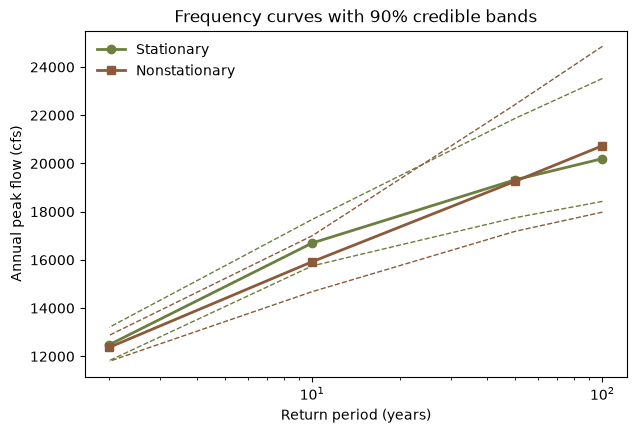

In [9]:
rp = [1 / a for a in aeps]

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, fit, color, marker in (("Stationary", fit_st, "#6b7f3f", "o"),
                                  ("Nonstationary", fit_ns, "#8c5a3b", "s")):
    ax.plot(rp, fit["mode_curve"], marker=marker, color=color, lw=2, label=label)
    ax.plot(rp, fit["lower_ci"], ls="--", color=color, lw=1)
    ax.plot(rp, fit["upper_ci"], ls="--", color=color, lw=1)
ax.set_xscale("log")
ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual peak flow (cfs)")
ax.set_title("Frequency curves with 90% credible bands")
ax.legend(frameon=False)
plt.show()

## Other trends

`trend()` accepts eleven shapes. `"Linear"` is the usual starting point; `"StepFunction"`
suits a record split by a dam closure; `"Quadratic"` and `"Exponential"` allow
acceleration. A trend can go on any parameter, so a record whose variability is growing
while its mean holds steady is a trend on the scale, not the location.

In [10]:
ch.model_univariate(
    "GeneralizedExtremeValue", peaks,
    trends=[ch.trend("location", "Linear"), ch.trend("scale", "Linear")],
)

<Model univariate_distribution: GeneralizedExtremeValue (60 exact; 2 trends)>

## Reproduction check

In [11]:
# The series is a seeded draw and both fits are seeded, so these literals are what this
# port computes -- and the R version asserts exactly the same ones, which is what proves
# the cross-language identity. Both packages run the same compiled core with a bit-exact
# Mersenne Twister, so the match is exact here rather than merely close.
assert len(peaks) == 60
assert peaks[0] == 13061
assert peaks[59] == 18259
assert len(ch.model_parameters(stationary)["values"]) == 3
assert len(ch.model_log_likelihood(nonstationary)["parameters"]) == 4
assert ch.model_log_likelihood(nonstationary)["parameters"][1] == 0

assert fit_st["parameters"] == [
    11466.959671080613, 2869.2711878151431, 0.19393823011146949
]
assert fit_ns["parameters"] == [
    11709.988016136142, 1791.8788376812713, -0.038823969138550476
]

assert fit_st["aic"] == 1206.638960039714
assert fit_st["bic"] == 1212.9219937263804
assert fit_st["dic"] == 1132.4743356411248
assert fit_ns["aic"] == 1187.5666019184123
assert fit_ns["bic"] == 1195.9439801673007
assert fit_ns["dic"] == 1089.384392412717

assert fit_st["mode_curve"][0] == 20199.188170270245
assert fit_ns["mode_curve"][0] == 20734.822267634547

# Internal consistency: all three criteria prefer the nonstationary model, every
# frequency curve decreases as the exceedance probability rises, and each credible band
# brackets its own curve.
assert fit_ns["aic"] < fit_st["aic"]
assert fit_ns["bic"] < fit_st["bic"]
assert fit_ns["dic"] < fit_st["dic"]
for fit in (fit_st, fit_ns):
    q = fit["mode_curve"]
    assert all(b < a for a, b in zip(q, q[1:]))
    assert all(lo <= m for lo, m in zip(fit["lower_ci"], q))
    assert all(hi >= m for hi, m in zip(fit["upper_ci"], q))
print("All reproduction checks passed.")

All reproduction checks passed.


## References

Coles, S. (2001). *An Introduction to Statistical Modeling of Extreme Values*, Chapter 6.
Springer.

Salas, J.D., and Obeysekera, J. (2014). Revisiting the concepts of return period and
risk for nonstationary hydrologic extreme events. *Journal of Hydrologic Engineering*
19(3), 554-568.